In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_csv('/content/sample_data/UCI_Credit_Card.csv')

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nClass Distribution:\n{df['default.payment.next.month'].value_counts()}")
print(f"Default Rate: {df['default.payment.next.month'].mean()*100:.2f}%")

DATASET OVERVIEW
Shape: (30000, 25)

First 5 rows:
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  de

In [8]:
print("\n" + "=" * 60)
print("STEP 2: PREPROCESSING")
print("=" * 60)

df.drop(columns=['ID'], inplace=True)

df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
df['MARRIAGE']  = df['MARRIAGE'].replace({0: 3})

features = ['AGE', 'LIMIT_BAL', 'EDUCATION', 'MARRIAGE',
            'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
target = 'default.payment.next.month'

X = df[features].copy()
y = df[target].copy()

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train size : {X_train.shape[0]}")
print(f"Test  size : {X_test.shape[0]}")
print(f"Train default rate: {y_train.mean()*100:.2f}%")
print(f"Test  default rate: {y_test.mean()*100:.2f}%")


STEP 2: PREPROCESSING
Train size : 24000
Test  size : 6000
Train default rate: 22.12%
Test  default rate: 22.12%


In [9]:
results = {}

def train_evaluate(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm  = confusion_matrix(y_test, y_pred)
    rep = classification_report(y_test, y_pred, output_dict=True)
    results[name] = {'model': model, 'y_pred': y_pred, 'acc': acc, 'cm': cm, 'report': rep}
    print(f"  {name:<30}  Accuracy: {acc*100:.2f}%")


print("\n" + "=" * 60)
print("SVM MODELS")
print("=" * 60)
train_evaluate('SVM - Linear',      SVC(kernel='linear', C=1.0, random_state=42))
train_evaluate('SVM - Polynomial',  SVC(kernel='poly', degree=3, C=1.0, random_state=42))
train_evaluate('SVM - RBF',         SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))

print("\n" + "=" * 60)
print("KNN MODELS")
print("=" * 60)
for k in [3, 5, 7]:
    train_evaluate(f'KNN - k={k}', KNeighborsClassifier(n_neighbors=k))


SVM MODELS
  SVM - Linear                    Accuracy: 80.80%
  SVM - Polynomial                Accuracy: 80.03%
  SVM - RBF                       Accuracy: 81.88%

KNN MODELS
  KNN - k=3                       Accuracy: 78.08%
  KNN - k=5                       Accuracy: 79.83%
  KNN - k=7                       Accuracy: 80.60%


In [10]:
print("\n" + "=" * 60)
print("CLASSIFICATION REPORTS")
print("=" * 60)
for name, res in results.items():
    print(f"\n{'-'*50}")
    print(f"  {name}")
    print(f"{'-'*50}")
    print(classification_report(y_test, res['y_pred'], target_names=['No Default', 'Default']))


CLASSIFICATION REPORTS

--------------------------------------------------
  SVM - Linear
--------------------------------------------------
              precision    recall  f1-score   support

  No Default       0.82      0.97      0.89      4673
     Default       0.68      0.25      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.61      0.62      6000
weighted avg       0.79      0.81      0.77      6000


--------------------------------------------------
  SVM - Polynomial
--------------------------------------------------
              precision    recall  f1-score   support

  No Default       0.81      0.98      0.88      4673
     Default       0.71      0.17      0.27      1327

    accuracy                           0.80      6000
   macro avg       0.76      0.57      0.58      6000
weighted avg       0.78      0.80      0.75      6000


--------------------------------------------------
  SVM - RBF
------------------

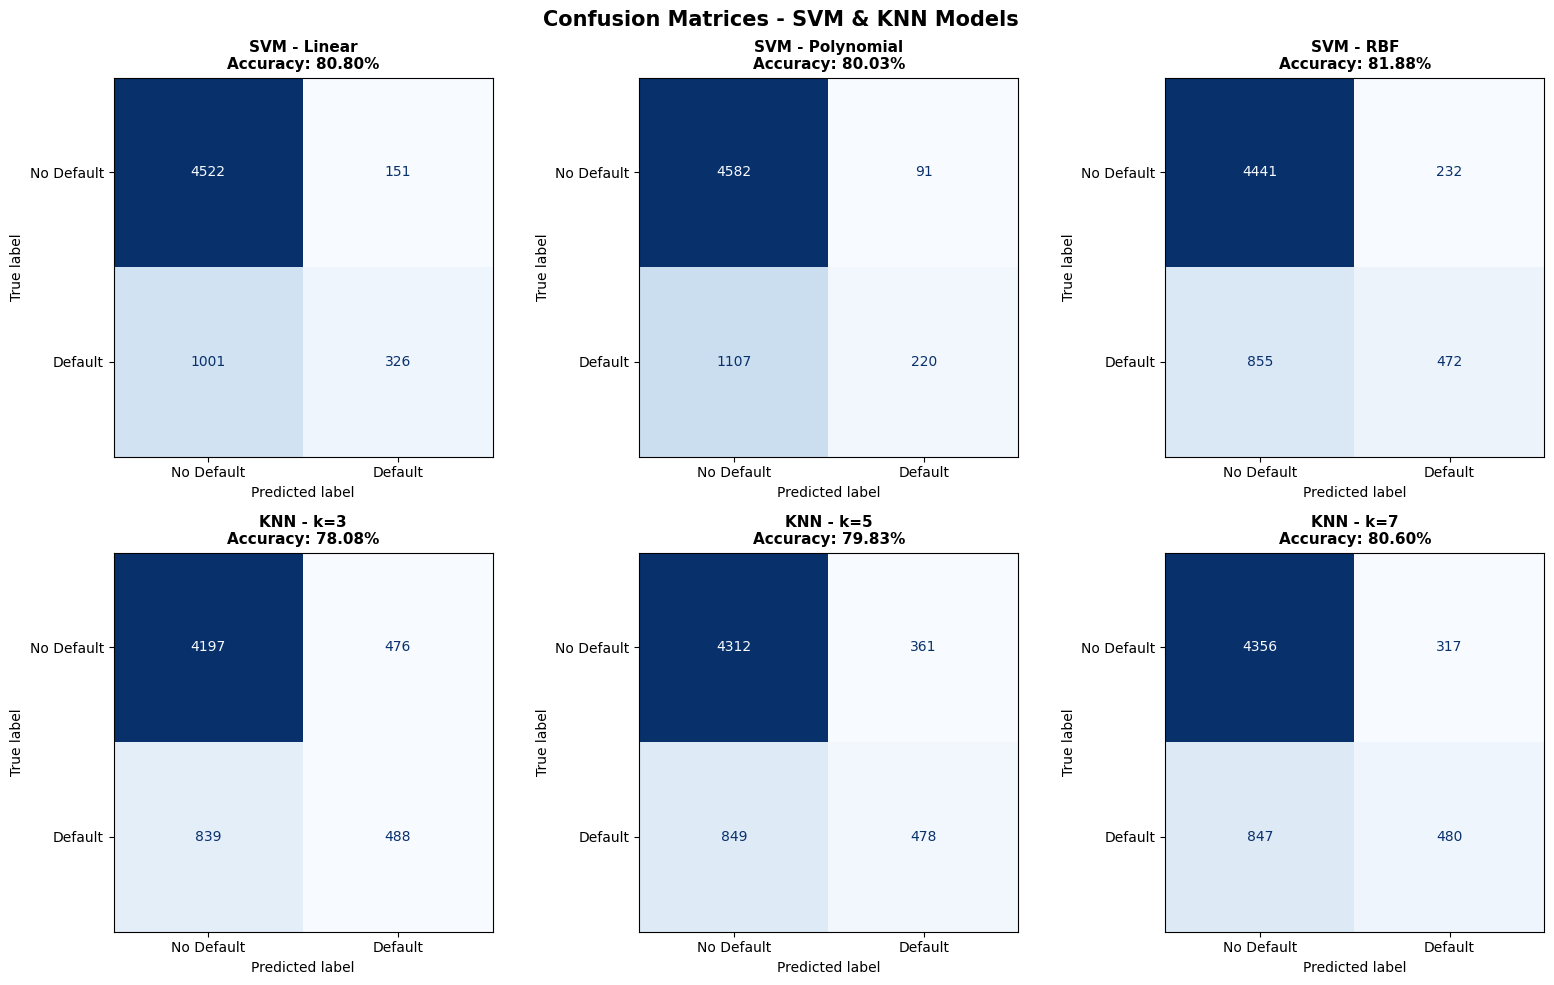

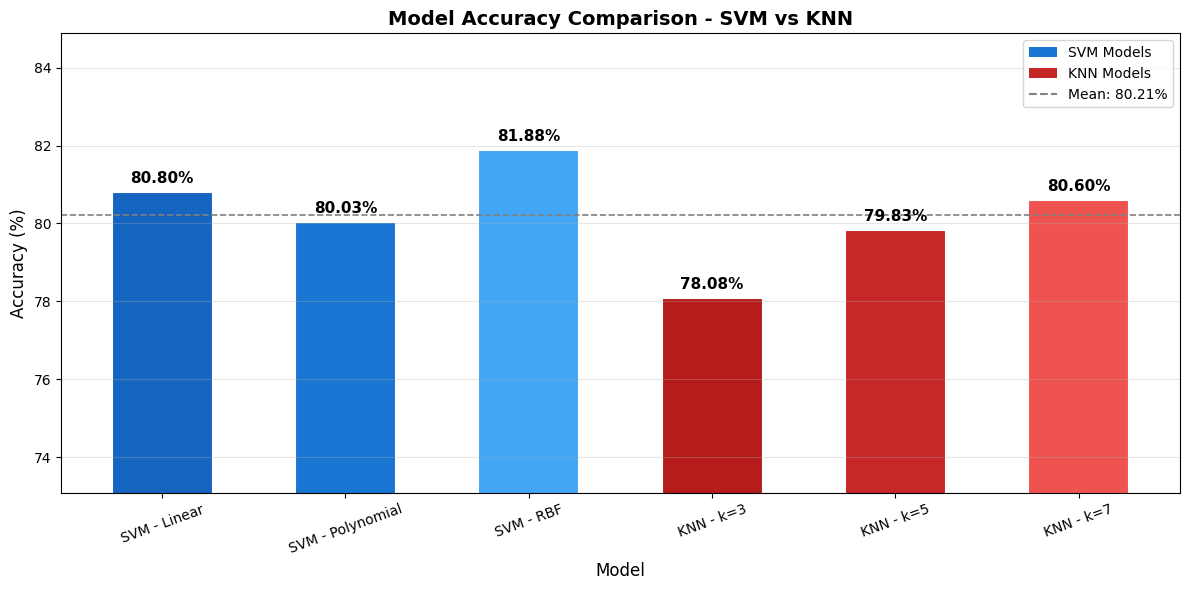

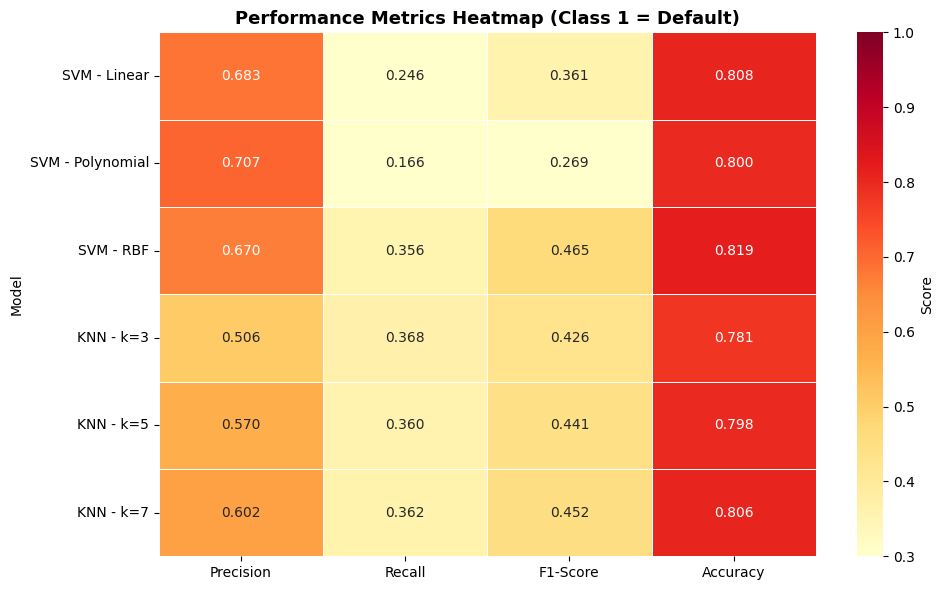

In [11]:
# Plot 1: Confusion Matrices
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Confusion Matrices - SVM & KNN Models', fontsize=15, fontweight='bold')

for idx, (name, res) in enumerate(results.items()):
    ax = axes.flatten()[idx]
    disp = ConfusionMatrixDisplay(confusion_matrix=res['cm'],
                                  display_labels=['No Default', 'Default'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nAccuracy: {res['acc']*100:.2f}%", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


# Plot 2: Accuracy Comparison
fig2, ax = plt.subplots(figsize=(12, 6))

names  = list(results.keys())
accs   = [results[n]['acc'] * 100 for n in names]
colors = ['#1565C0', '#1976D2', '#42A5F5', '#B71C1C', '#C62828', '#EF5350']

bars = ax.bar(names, accs, color=colors, edgecolor='white', linewidth=1.5, width=0.55)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylim(min(accs) - 5, max(accs) + 3)
ax.set_title('Model Accuracy Comparison - SVM vs KNN', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.tick_params(axis='x', rotation=20)
ax.axhline(y=np.mean(accs), color='gray', linestyle='--', linewidth=1.2)
ax.legend(handles=[
    Patch(facecolor='#1976D2', label='SVM Models'),
    Patch(facecolor='#C62828', label='KNN Models'),
    plt.Line2D([0], [0], color='gray', linestyle='--', label=f'Mean: {np.mean(accs):.2f}%')
], fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


# Plot 3: Metrics Heatmap
metrics_rows = []
for name, res in results.items():
    rep = res['report']
    metrics_rows.append({
        'Model'    : name,
        'Precision': round(rep['1']['precision'], 3),
        'Recall'   : round(rep['1']['recall'], 3),
        'F1-Score' : round(rep['1']['f1-score'], 3),
        'Accuracy' : round(res['acc'], 3)
    })

metrics_df = pd.DataFrame(metrics_rows).set_index('Model')

fig3, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(metrics_df, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Score'}, vmin=0.3, vmax=1.0)
ax.set_title('Performance Metrics Heatmap (Class 1 = Default)', fontsize=13, fontweight='bold')
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('metrics_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
print("\n" + "=" * 60)
print("FINAL SUMMARY TABLE")
print("=" * 60)
print(metrics_df.to_string())

best = max(results, key=lambda n: results[n]['acc'])
print(f"\nBest Model : {best}")
print(f"Accuracy   : {results[best]['acc']*100:.2f}%")


FINAL SUMMARY TABLE
                  Precision  Recall  F1-Score  Accuracy
Model                                                  
SVM - Linear          0.683   0.246     0.361     0.808
SVM - Polynomial      0.707   0.166     0.269     0.800
SVM - RBF             0.670   0.356     0.465     0.819
KNN - k=3             0.506   0.368     0.426     0.781
KNN - k=5             0.570   0.360     0.441     0.798
KNN - k=7             0.602   0.362     0.452     0.806

Best Model : SVM - RBF
Accuracy   : 81.88%
